In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:10]

['thiv',
 'ziyan',
 'del',
 'bharathushan',
 'aranamuthan',
 'saptahotre',
 'lakshay',
 'mangaraj',
 'gopitha',
 'jeylani']

In [3]:
print("Number of names", len(words))
print("Min Length", min(len(w) for w in words))
print("Max Length", max(len(w) for w in words))

Number of names 114240
Min Length 1
Max Length 15


In [4]:
words = [w for w in words if len(w) >= 3]

print("Number of names", len(words))
print("Min Length", min(len(w) for w in words))
print("Max Length", max(len(w) for w in words))

Number of names 113900
Min Length 3
Max Length 15


In [5]:
# exploring bi-grams

for w in words[:1]:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        print(ch1, ch2)

<S> t
t h
h i
i v
v <E>


#### Counting Occurances

So in bi-gram what we can do is count the occurances of "how many times h is coming after t" and like this for every pair.

In [6]:
b = {}

for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

print(b)

{('<S>', 't'): 5344, ('t', 'h'): 18011, ('h', 'i'): 11753, ('i', 'v'): 2600, ('v', '<E>'): 695, ('<S>', 'z'): 973, ('z', 'i'): 424, ('i', 'y'): 2491, ('y', 'a'): 10395, ('a', 'n'): 40151, ('n', '<E>'): 22485, ('<S>', 'd'): 6344, ('d', 'e'): 3334, ('e', 'l'): 4493, ('l', '<E>'): 3253, ('<S>', 'b'): 5107, ('b', 'h'): 4278, ('h', 'a'): 31538, ('a', 'r'): 22305, ('r', 'a'): 21916, ('a', 't'): 10336, ('h', 'u'): 4286, ('u', 's'): 3249, ('s', 'h'): 23232, ('<S>', 'a'): 12268, ('n', 'a'): 16572, ('a', 'm'): 10082, ('m', 'u'): 1855, ('u', 't'): 2261, ('<S>', 's'): 13286, ('s', 'a'): 8759, ('a', 'p'): 3175, ('p', 't'): 256, ('t', 'a'): 7678, ('a', 'h'): 5971, ('h', 'o'): 1372, ('o', 't'): 902, ('t', 'r'): 2454, ('r', 'e'): 4174, ('e', '<E>'): 8597, ('<S>', 'l'): 3262, ('l', 'a'): 9816, ('a', 'k'): 6780, ('k', 's'): 2327, ('a', 'y'): 6361, ('y', '<E>'): 3399, ('<S>', 'm'): 8581, ('m', 'a'): 13588, ('n', 'g'): 2028, ('g', 'a'): 5670, ('a', 'j'): 4006, ('j', '<E>'): 1008, ('<S>', 'g'): 3387, ('g',

In [7]:
# analysis on the bigrams generated
sorted(b.items(), key=lambda kv: kv[1])[:10] # 10 most least occuring bigrams

[(('j', 'z'), 1),
 (('h', 'x'), 1),
 (('c', 'w'), 1),
 (('q', 'k'), 1),
 (('p', 'q'), 1),
 (('w', 'c'), 1),
 (('c', 'p'), 1),
 (('c', 'd'), 1),
 (('q', 'c'), 1),
 (('w', 'q'), 1)]

In [11]:
N = torch.zeros((27, 27), dtype=torch.int32)
chars = sorted(list(set(char for w in words for char in w)))

stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0

itos = {i: s for s, i in stoi.items()}

In [12]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1


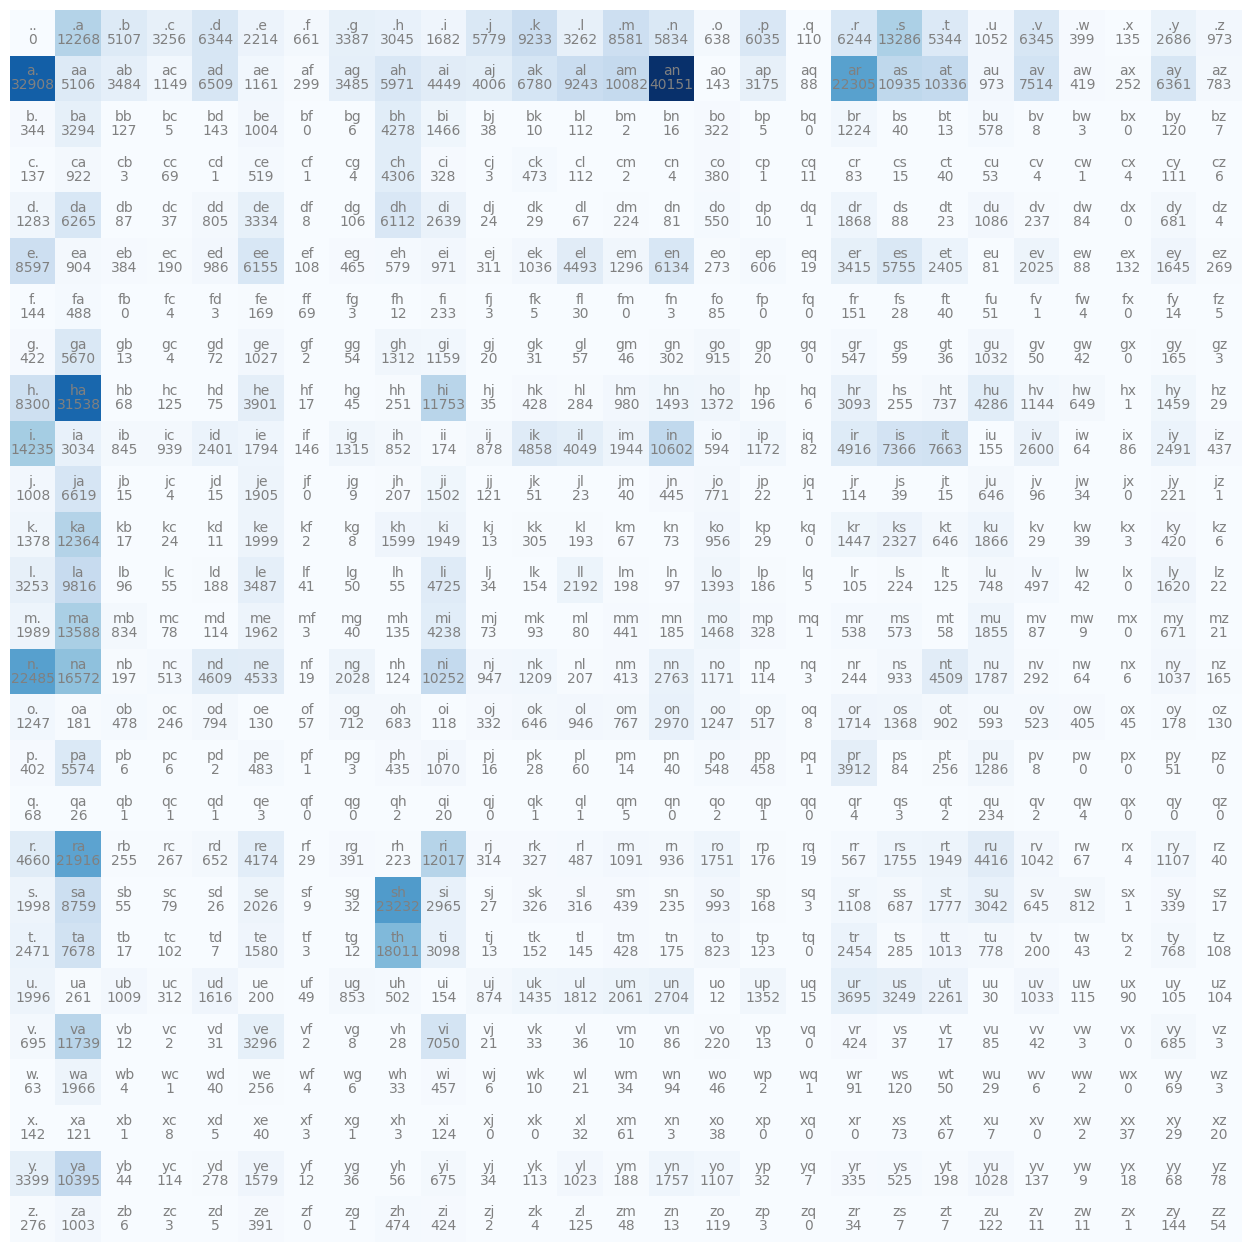

In [13]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray')

plt.axis('off')
plt.show()

In [14]:
N[0]

tensor([    0, 12268,  5107,  3256,  6344,  2214,   661,  3387,  3045,  1682,
         5779,  9233,  3262,  8581,  5834,   638,  6035,   110,  6244, 13286,
         5344,  1052,  6345,   399,   135,  2686,   973], dtype=torch.int32)

In [21]:
p = N[0].float()
p = p / p.sum()
print(p)


tensor([0.0000, 0.1077, 0.0448, 0.0286, 0.0557, 0.0194, 0.0058, 0.0297, 0.0267,
        0.0148, 0.0507, 0.0811, 0.0286, 0.0753, 0.0512, 0.0056, 0.0530, 0.0010,
        0.0548, 0.1166, 0.0469, 0.0092, 0.0557, 0.0035, 0.0012, 0.0236, 0.0085])


In [24]:
g = torch.Generator().manual_seed(2147483647)
idx = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[idx]

'd'

In [ ]:
# g = torch.Generator().manual_seed(2147483647)
# p = torch.rand(3, generator=g)
# p = p / p.sum()
# p

tensor([0.6064, 0.3033, 0.0903])

From the given probabilistic distribution
- we would expect 60% of the values to be 0
- 30% to be 1
- and we would expect remaining ~10% to be 2 

In [ ]:
# torch.multinomial(p, num_samples=20, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1])

In [61]:
P = (N+1).float()
P.sum(1, keepdim=True) # row wise sum (dim = 1) -- shape -> (27, 1)

tensor([[113927.],
        [198094.],
        [ 13192.],
        [  7620.],
        [ 25760.],
        [ 49349.],
        [  1572.],
        [ 13087.],
        [ 72547.],
        [ 75719.],
        [ 13951.],
        [ 27797.],
        [ 29435.],
        [ 29489.],
        [ 77223.],
        [ 17964.],
        [ 14771.],
        [   408.],
        [ 60659.],
        [ 50143.],
        [ 40516.],
        [ 27926.],
        [ 24605.],
        [  3441.],
        [   844.],
        [ 23272.],
        [  3315.]])

In [63]:
P = (N+1).float()
# (27, 27) / (27, 1)
P = P / P.sum(1, keepdim=True)

# verify
P[0].sum() # --> should give 1

tensor(1.)

In [64]:
g = torch.Generator().manual_seed(2147483647)

for i in range(20):
    out = []
    idx = 0
    while True:

        p = P[idx]
        # p = N[idx].float()
        # p = p / p.sum()

        idx = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[idx])
        if idx == 0:
            break

    print(''.join(out))

dexze.
mogakurari.
zitaharvinimittain.
llavi.
ka.
da.
samithubrtharugotas.
molishanauja.
preda.
ka.
davamsade.
ankavirniratlsh.
hinivenvtahive.
dhshr.
ban.
gl.
pangaisana.
ra.
dineeezem.
desu.


### Observations

Bi-Gram models are actually very terrible and that is why we dont see some good actual name in results

Because if you see through the model, it doesnt know at which position we are getting what sequence, its just playing around with the probabilities of counts of occurance from the `names.txt`

> We took **multinomial** because if we had everything equally likely - all occurance are uniformly equally likely, we would get very very garbage value
So basically our bi-gram model is atleast better than that equally likely outcome model that throws utter garbage at us.

### Evaluation of Bi-gram model

- The loss function -- we would go with `-ve log likelihood`
- Since we cant directly prod all the probabilities -- would get very small value betweek 0 and 1
- we go with -ve log
- **log(abc) = log(a) + log(b) + log(c)**


> When all prob are 1 --> log likelihood would go to 0 \
So less the prob, more negative is the log likelihood \
Therefore we take -ve of that, or avg of -ve of that which we aim to minimize


#### Goal
- **Maximize** likelihood of the data w.r.t. model parameters (statistical modeling)
- Equivalent to **maximizing** the log likelihood (because log is monotonic)
- Equivalent to **minimizing** the *-ve log likelihood*
- Equivalent to **minimizing** the *average -ve log likelihood* 

In [67]:
log_likelihood = 0
n = 0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1][ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        # print(f"{ch1}{ch2}: {prob:.4f} {logprob:.4f}")

print(f"{log_likelihood=}")
nll = -log_likelihood
print(f"{nll=}")
print(f"Avg -ve Log Likelihood: {nll/n}")

log_likelihood=tensor(-2389474.)
nll=tensor(2389474.)
Avg -ve Log Likelihood: 2.3520829677581787
